# Preprocessing

## Download dataset

Scarichiamo il dataset con il codice fornito da *kaggle*

In [2]:
import kagglehub

# Download diretta da kaggle
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

c:\Users\Matteo\anaconda3\envs\DL\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Matteo\.cache\kagglehub\datasets\msambare\fer2013\versions\1


## Visualizzazione immagini

Visualizziamo 12 immagini assieme alle rispettive etichette per farci un'idea delle immagini che compongono il dataset 

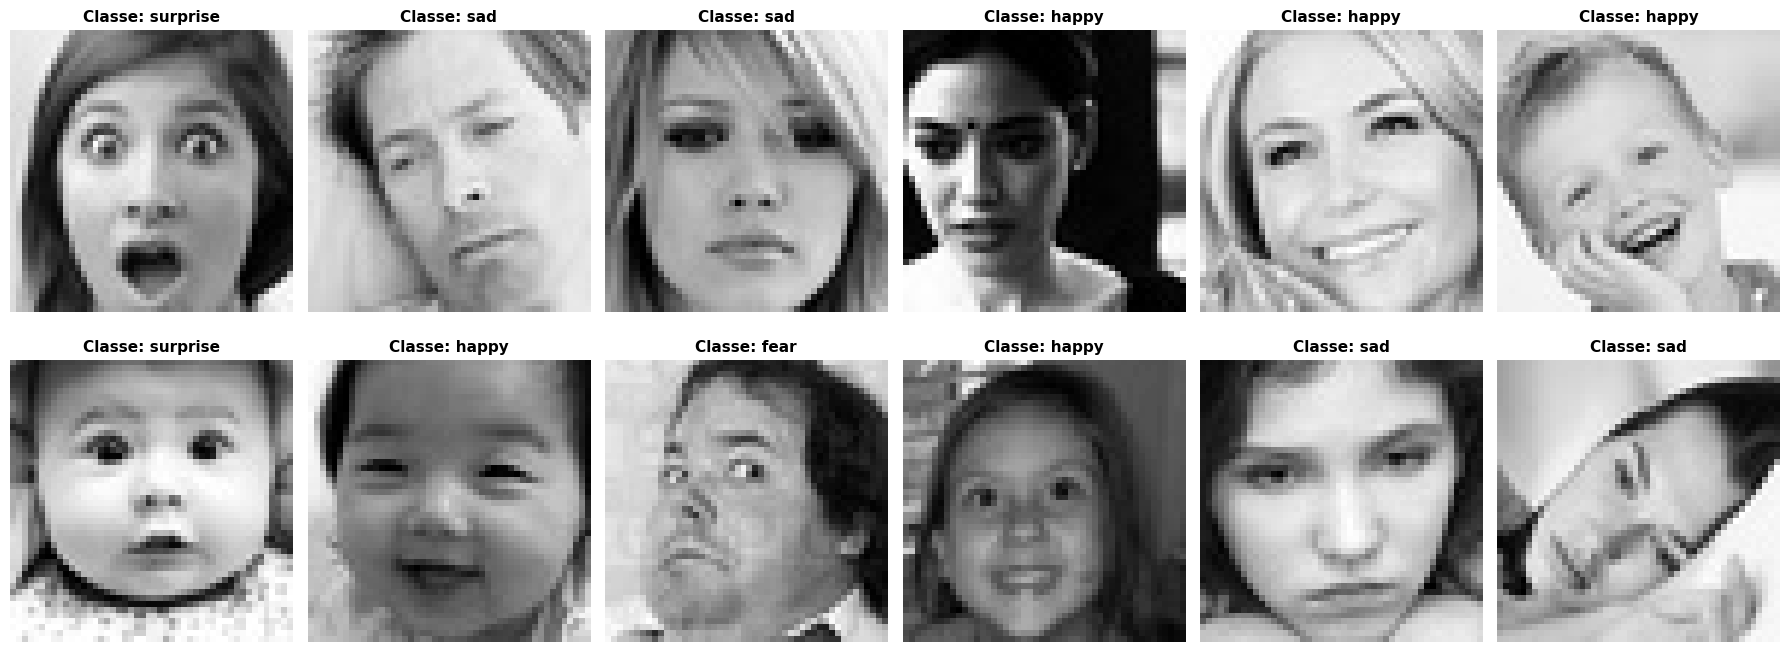

In [3]:

import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


dataset_path = Path(path)

valid_extensions = [".jpg"]
all_images = [
    p for p in dataset_path.rglob("*") if p.suffix.lower() in valid_extensions
]

if not all_images:
    print(
        f"Nessuna immagine presente nel percorso: {dataset_path}"
    )
else:
    num_samples = 12
    samples = random.sample(all_images, min(num_samples, len(all_images)))

    num_rows = 2
    num_cols = 6

    plt.figure(figsize=(18, 7))

    for idx, img_path in enumerate(samples):
        emotion_class = img_path.parent.name
        title = f"Classe: {emotion_class}"

        img = Image.open(img_path)

        plt.subplot(num_rows, num_cols, idx + 1)

        plt.imshow(img, cmap="gray" if img.mode == "L" else None)
        plt.title(title, fontsize=11, fontweight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Preprocessing

Utilizziamo una funzione per applicare delle leggere modifice alle immagini per generare più campioni.
Le tecniche di preprocessing che andremo ad applicare sono:
- Flip orizzontale
- Traslazione
- Rotazione
- Zoom
- Normalizzazione 

'\nimg = Image.open(path_img)\n\nimg_np = np.array(img)\n\n# plot the pixel values\nplt.hist(img_np.ravel(), bins=50, density=True)\nplt.xlabel("pixel values")\nplt.ylabel("relative frequency")\nplt.title("distribution of pixels")\nplt.imshow(img_np)\n'

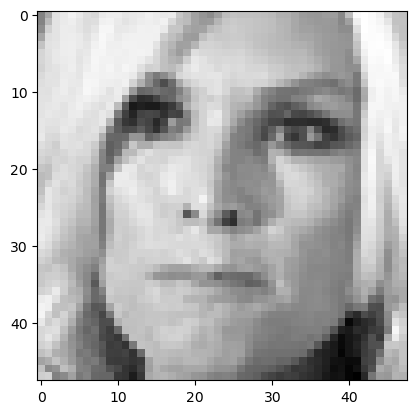

In [15]:
import numpy as np

path_img=r'C:\Users\Matteo\.cache\kagglehub\datasets\msambare\fer2013\versions\1\train\angry\Training_33331.jpg'
img1 = Image.open(path_img)
plt.imshow(img1, cmap="gray")

'''
img = Image.open(path_img)

img_np = np.array(img)

# plot the pixel values
plt.hist(img_np.ravel(), bins=50, density=True)
plt.xlabel("pixel values")
plt.ylabel("relative frequency")
plt.title("distribution of pixels")
plt.imshow(img_np)
'''


Preprocessazione immagini - esempio con una immagine

Text(0.5, 1.0, 'distribution of pixels')

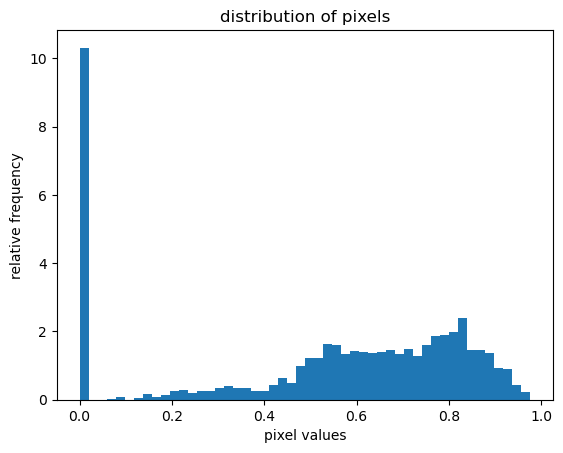

In [16]:
import torchvision.transforms as transforms

# Pipeline per preprocessing
def get_preprocessing_pipeline():
    preprocessing = transforms.Compose(
        [
            # 1. Flip Orizzontale casuale
            transforms.RandomHorizontalFlip(p=0.5),
            
            # 2. Rotazione casuale
            transforms.RandomRotation(degrees=15, fill=0),
            
            # 3. Traslazione e Zoom leggero
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), fill=0),
            
            # Conversione in tensore
            transforms.ToTensor(),
            
            # 5. Normalizzazione
            #transforms.Normalize(mean=[0.5], std=[0.5])
        ]
    )
    return preprocessing

pipeline = get_preprocessing_pipeline()
img = Image.open(path_img)
img_tensor = pipeline(img)

# Riconvertiamo le immagini da tensore a immagine
img_per_vis = img_tensor.permute(1,2,0).numpy()

if img_per_vis.shape[2] == 1:
    img_per_vis = img_per_vis.squeeze(axis=2)

#plt.imshow(img_per_vis, cmap="gray")


# plot the pixel values
plt.hist(img_tensor.ravel(), bins=50, density=True)
plt.xlabel("pixel values")
plt.ylabel("relative frequency")
plt.title("distribution of pixels")


In [21]:
import random
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

# --- 1. CONFIGURAZIONE PERCORSI ASSOLUTI SUL TUO PC ---
# La cartella da dove prendiamo le immagini di origine
dataset_originale_path = Path(r"C:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\original\train")

# La cartella di destinazione (attualmente vuota) dove salveremo i file elaborati
dataset_processed_path = Path(r"C:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed")


# --- 2. PIPELINE E FUNZIONE DI RIPRISTINO TENSORE ---
pipeline = get_preprocessing_pipeline()

def tensor_to_saved_image(tensor):
    """Denormalizza il tensore di PyTorch e lo riporta a una immagine PIL."""
    tensor = tensor * 0.5 + 0.5  # Inverte la normalizzazione mean=0.5, std=0.5
    tensor = tensor.clamp(0, 1)  # Mantiene i pixel nel range corretto
    reverse_transform = transforms.ToPILImage()
    return reverse_transform(tensor)


# --- 3. LETTURA E SELEZIONE CASUALE DAL DATASET ORIGINALE ---
valid_extensions = [".jpg", ".jpeg", ".png"]
# Cerchiamo tutti i file dentro 'data/original'
all_images = [p for p in dataset_originale_path.rglob("*") if p.suffix.lower() in valid_extensions]

percentuale_da_prendere = 0.20  # Prendiamo il 20% delle immagini totali
num_immagini_da_preprocessare = int(len(all_images) * percentuale_da_prendere)
immagini_selezionate = random.sample(all_images, num_immagini_da_preprocessare)

print(f"🔄 Inizio elaborazione di {num_immagini_da_preprocessare} immagini...")

# --- 4. CICLO DI ELABORAZIONE E CREAZIONE STRUTTURA ---
for img_path in immagini_selezionate:
    
    # 💡 LA MAGIA DEL PERCORSO RELATIVO:
    # Se img_path è:        .../data/original/train/happy/im0.jpg
    # E il percorso base è: .../data/original
    # 'relativo_path' sarà solo: train/happy/im0.jpg
    relativo_path = img_path.relative_to(dataset_originale_path)
    
    # Ora uniamo la nuova cartella 'processed' con il pezzetto relativo.
    # Diventa: C:\Users\Matteo\Desktop\FaceFERward\data\processed\train\happy\im0.jpg
    nuovo_percorso_file = dataset_processed_path / relativo_path
    
    # 🔥 STRUTTURA AUTOMATICA: 
    # .parent estrae la cartella (es. C:\...\processed\train\happy)
    # .mkdir con parents=True crea l'intera catena di cartelle mancanti!
    nuovo_percorso_file.parent.mkdir(parents=True, exist_ok=True)
    
    # (Opzionale) Cambiamo leggermente il nome per far capire che è modificata, es: im0_processed.jpg
    nuovo_percorso_file = nuovo_percorso_file.with_name(f"{img_path.stem}_processed{img_path.suffix}")

    try:
        # 1. Apriamo l'immagine da 'original'
        img_originale = Image.open(img_path)
        
        # 2. Applichiamo le modifiche con PyTorch
        img_tensor = pipeline(img_originale)
        
        # 3. Riconvertiamo in formato salvabile
        img_da_salvare = tensor_to_saved_image(img_tensor)
        
        # 4. Salviamo nella cartella 'processed' dentro la sottocartella corretta
        img_da_salvare.save(nuovo_percorso_file)
        
    except Exception as e:
        print(f"Errore con il file {img_path.name}: {e}")

print(f"🎉 Fatto! Ora controlla la cartella 'processed', troverai la stessa struttura di 'original'.")

🔄 Inizio elaborazione di 5741 immagini...
🎉 Fatto! Ora controlla la cartella 'processed', troverai la stessa struttura di 'original'.


#### Controllo cartelle

In [26]:
import os
from pathlib import Path

# 1. Trova automaticamente la cartella in cui si trova QUESTO notebook
# (Funziona sia su Jupyter Notebook, sia su VS Code, sia su script standard)
notebook_dir = Path(os.getcwd())
print(notebook_dir)

# 2. Risali alla cartella principale del progetto (la cartella "root")
# Se il tuo notebook è dentro la cartella 'notebooks', il suo genitore (.parent) è la radice del progetto
project_root = notebook_dir.parent
print(project_root)

# 3. Costruisci il percorso verso la cartella test in modo dinamico
# Non serve scrivere il nome della cartella principale, basta puntare a data/processed/test
testpath = project_root / "data" / "processed"
print(testpath)

# 4. Verifica se esiste
if testpath.exists():
    print(f"✅ La cartella esiste nel percorso: {testpath}")
else:
    print(f"❌ La cartella NON esiste. Percorso cercato: {testpath}")

c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\notebooks
c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward
c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed
✅ La cartella esiste nel percorso: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed
